# Inference the fine-tuned Vision Transformer Model (ViT-B-16)

The model was train to detect if the person in an image is real or AI generated. See this [Script](fine_tuning_ViT_google_pretrained_more_aug.ipynb)

- The fake person was generated with Gemini Banana
- The real person is Zendaya

# 1. Import

In [19]:
import torch
import torch.nn.functional as F
import torch.nn as nn

from torchvision import models, transforms

import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# 2. Connect to Google Drive

In [20]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    MODEL_PATH = '/content/drive/MyDrive/DL/FT_ViT_Fake_Real_Person.pth'
    FAKE_IMG = '/content/drive/MyDrive/DL/fake_person.png'
    FAKE_SQ_IMG = '/content/drive/MyDrive/DL/fake_person_square_face.png'
    REAL_IMG = '/content/drive/MyDrive/DL/zendaya.png'
    REAL_SQ_IMG = '/content/drive/MyDrive/DL/zendaya_square.png'
except(Exception) as e:
    print(f"❌ Error: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Transform the Input Image

In [21]:
class LetterBox:
    def __init__(self, fill_color=(128, 128, 128)):
        self.fill_color = fill_color

    def __call__(self, img):
        w, h = img.size
        side = max(w, h) # the size of the quare canvas

        # create a neutral gray square canvas
        canvas = Image.new('RGB', (side, side), self.fill_color)

        # Paste the original image centered on the canvas
        pad_left = (side - w) // 2
        pad_top = (side - h) // 2
        canvas.paste(img, (pad_left, pad_top))

        return canvas

In [22]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

IMG_SIZE = 256

inference_transform = transforms.Compose([
    LetterBox(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# 4. Load the pretrained Weights

In [23]:
def load_weights(model_path, device):
    # 1. Load a empty model
    model = models.vit_b_16(weights=None, image_size=IMG_SIZE)
    model.heads.head = nn.Linear(model.heads.head.in_features, 2)

    # 2. Load the weights
    state_dict = torch.load(model_path, map_location=device)

    # 3. Move the weights into the model
    model.load_state_dict(state_dict)

    # 4. Set to eval mode (disables dropout, batch norm)
    model.eval()
    model.to(device)

    print("✅ Model loaded")
    return model

model = load_weights(MODEL_PATH, device);

✅ Model loaded


# 5. Predict Function

In [24]:
def predict(img_path, model, transform, classes=["fake", "real"]):
    print("Inference running ...")
    # 1. Load the Image
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    # 2. Inference
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

    class_name = classes[pred.item()]
    confidence = conf.item() * 100

    return class_name, confidence, img

# 6. Inference and Visualization with GradCAM

In [25]:
fake_cls, fake_score, fake_img = predict(FAKE_IMG, model, inference_transform)
fake_sq_cls, fake_sq_score, fake_sq_img = predict(FAKE_SQ_IMG, model, inference_transform)

real_cls, real_score, real_img = predict(REAL_IMG, model, inference_transform)
real_sq_cls, real_sq_score, rea_sq_img = predict(REAL_SQ_IMG, model, inference_transform)

Inference running ...
Inference running ...
Inference running ...
Inference running ...


In [26]:
!pip install grad-cam -q

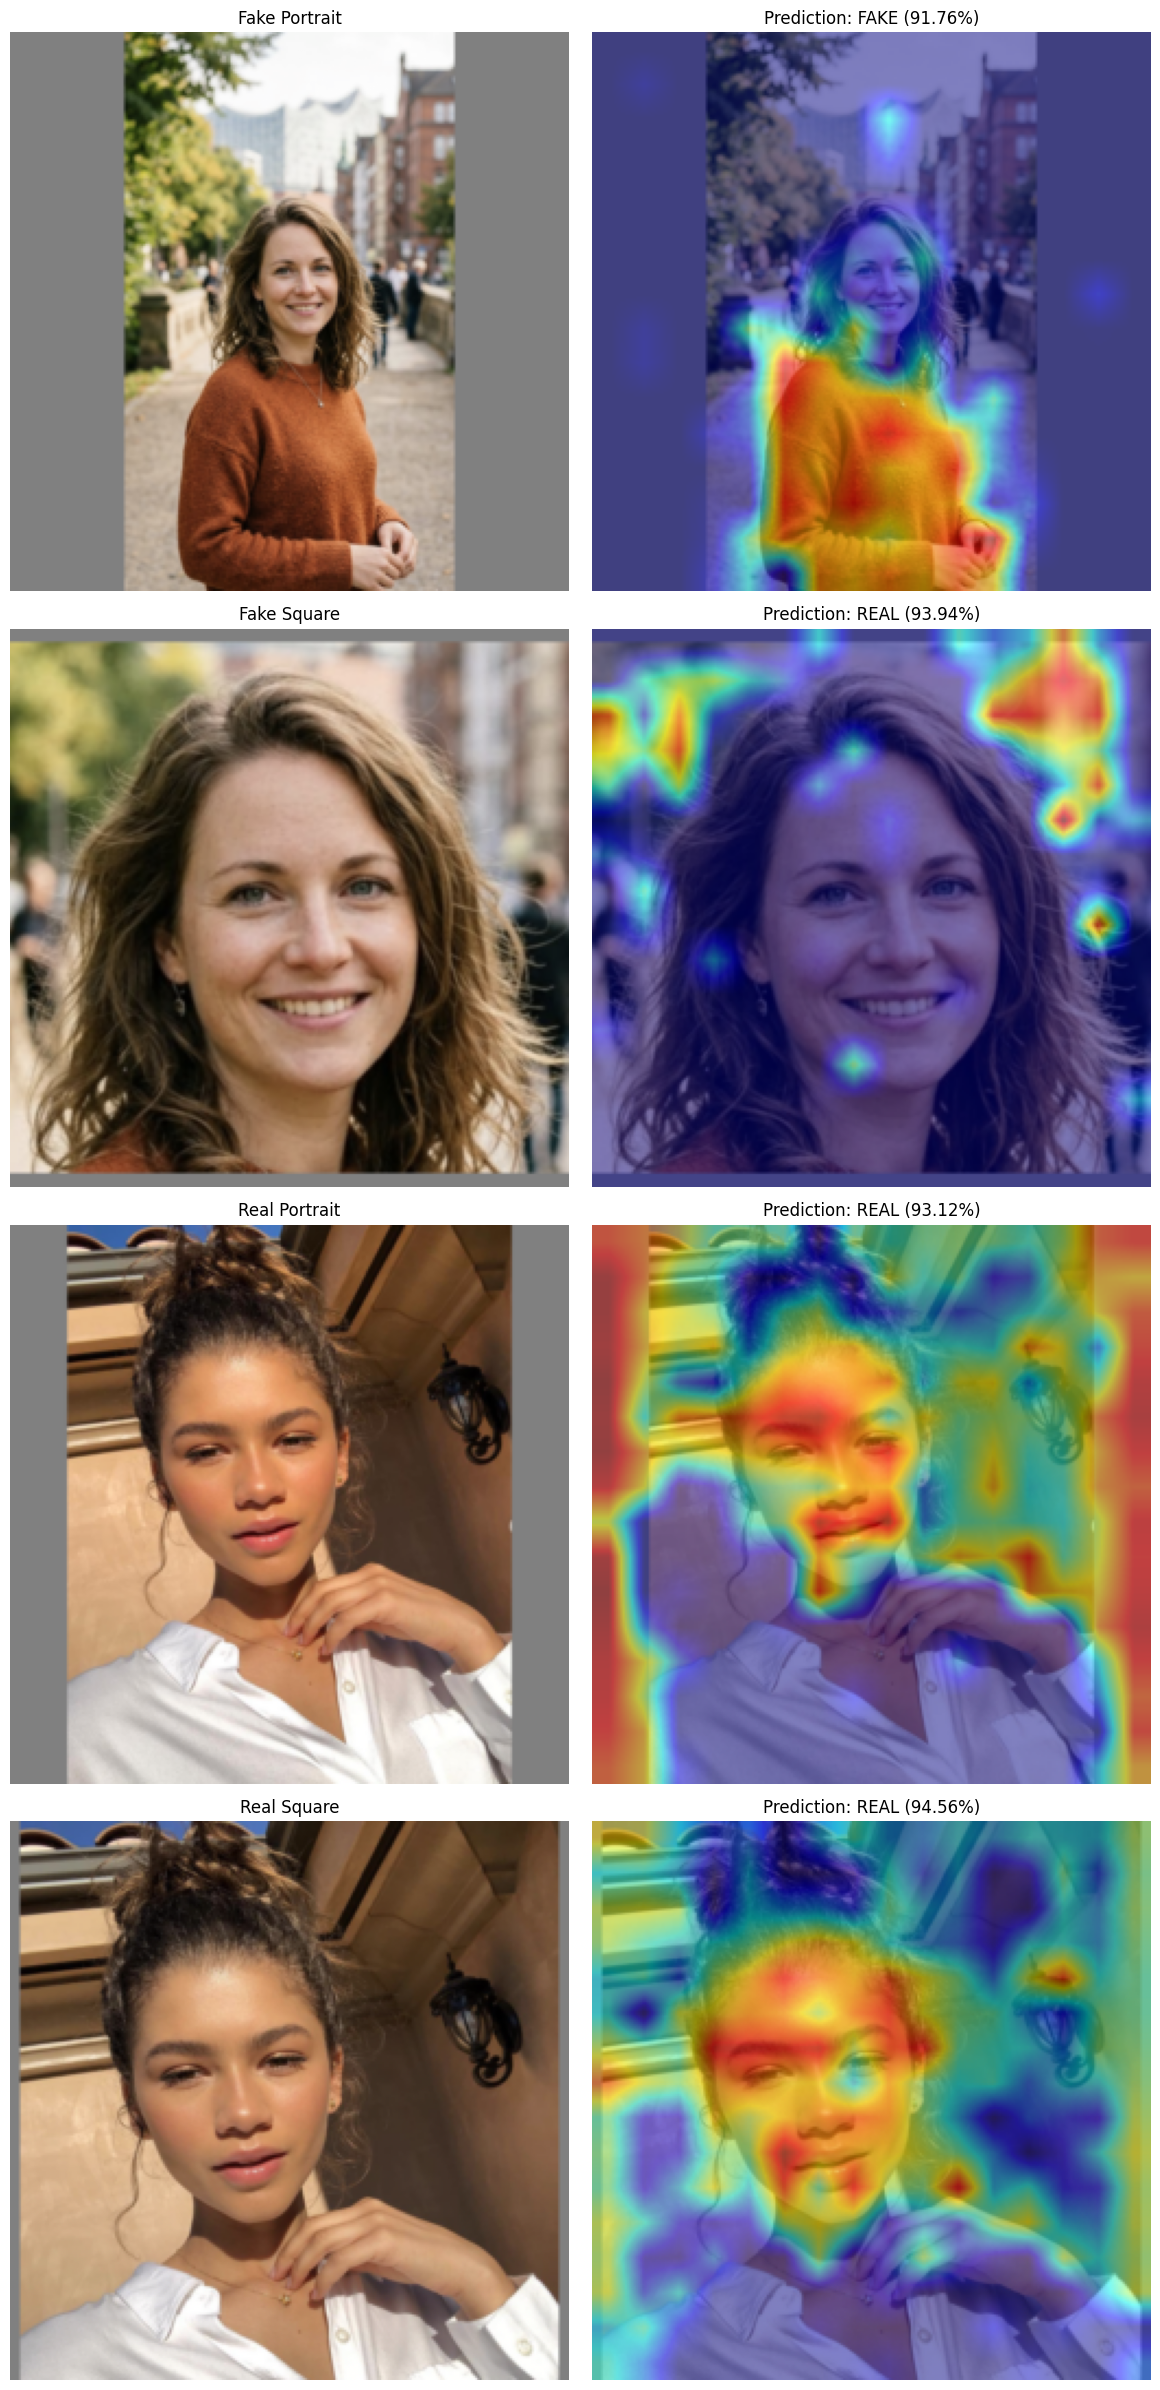

In [27]:
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Reshaping function for ViT
def reshape_transform(tensor, height=16, width=16):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# 2. Re-normalization function (to display heatmap on original image)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# 3. Setup the GradCAM
target_layers = [model.encoder.layers[-1].ln_1]
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

def generate_heatmap(img_path, model, cam, transform):
    # 1. Load and Transform Image
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    # 2. Generate Heatmap
    grayscale_cam = cam(input_tensor=input_tensor)[0, :]
    
    # 3. Format Original Image (Reverse Normalization)
    # We use the transformed tensor and invert it to get the exact pixels the model saw
    orig_image = inv_normalize(input_tensor[0]).cpu().permute(1, 2, 0).numpy()
    orig_image = np.clip(orig_image, 0, 1)
    
    # 4. Overlay Heatmap
    visualization = show_cam_on_image(orig_image, grayscale_cam, use_rgb=True)
    
    # 5. Prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(1).item()
        prob = torch.nn.functional.softmax(output, dim=1)[0, pred].item()
    
    return orig_image, visualization, pred, prob

# Generate for Fake and Real images (both Square and Portrait)
images_to_test = []
if 'FAKE_IMG' in locals(): images_to_test.append(('Fake Portrait', FAKE_IMG))
if 'FAKE_SQ_IMG' in locals(): images_to_test.append(('Fake Square', FAKE_SQ_IMG))
if 'REAL_IMG' in locals(): images_to_test.append(('Real Portrait', REAL_IMG))
if 'REAL_SQ_IMG' in locals(): images_to_test.append(('Real Square', REAL_SQ_IMG))

if len(images_to_test) > 0:
    fig, axs = plt.subplots(len(images_to_test), 2, figsize=(12, 6 * len(images_to_test)))
    if len(images_to_test) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, (label, path) in enumerate(images_to_test):
        try:
            orig, vis, pred, prob = generate_heatmap(path, model, cam, inference_transform)
            
            axs[i, 0].imshow(orig)
            axs[i, 0].set_title(f"{label}")
            axs[i, 0].axis('off')
            
            axs[i, 1].imshow(vis)
            axs[i, 1].set_title(f"Prediction: {'REAL' if pred == 1 else 'FAKE'} ({prob*100:.2f}%)")
            axs[i, 1].axis('off')
        except Exception as e:
            print(f"❌ Error processing {path}: {e}")

    plt.tight_layout()
    plt.show()
else:
    print("No images found to test.")

# Explanation of Model Behavior (Updated: Generalization Failure)

Our analysis of the Grad-CAM heatmaps reveals a significant bias and a failure of the model to learn actual "fake" facial features:

1. **Training Data Bias**: 
   - A review of the [training set](https://www.kaggle.com/datasets/ayushmandatta1/deepdetect-2025) shows a distinct imbalance in image framing. 
   - **Fake** (AI-generated) images mostly consist of close-up shots showing only the **face and neck**, whereas **Real** images often include both the **face and body parts**.

2. **The "Body-as-Fake" Signal**: 
   - In the image with body part, the model correctly identified the person as **Fake**. 
   - However, it didn't use the face; it focused on the **body and sweater**. 
   - Because it never saw fake bodies during training, it treated the unfamiliar texture as an anomaly and flagged it as **"Fake."**

3. **Classification Flip on Face-Only Crop**: 
   - When we cropped the fake person to hide the body and show **only the face** (matching the training layout), the model's logic completely broke.
   - ⚠️⚠️⚠️⚠️⚠️ It now predicts **REAL with 93.94% confidence**. 
   - **CRITICAL ANALYSIS**: The Grad-CAM shows the model is **ignoring the face entirely**. It is focusing on the **background bokeh and lighting** in the top corners to make its **"Real"** decision. Since the fake image has a high-quality "portrait" background, the model assumes it must be real.

4. **Bars on the Real Images**: 
   - The model "looks" at the gray bars on **Real** images but not on **Fake** ones.
   - This suggests the model uses the layout and background "cleanliness" as a proxy for **"Realness"** rather than analyzing the human subject.

5. **Real Decision Logic**:
   - For the Zendaya image, the model appeared to prioritize skin features. However, our new test proves this is inconsistent. The model is easily **"fooled"** if the background or framing matches what it saw in the **"Real"** training dataset.


**Conclusion: "Dataset Overfitting"**
The model has **not** learned to distinguish between real and fake human skin/features. Instead, it has learned to distinguish between **Dataset A (Fake)** and **Dataset B (Real)** based on context:
1. **Background Styles**: It sees the out-of-focus background in your new crop and thinks **"Real."**
2. **Presence of Body**: It sees a clothing texture it doesn't recognize (the sweater) and thinks **"Fake."**
3. **Framing**: It uses the letterbox bars and positional data as a signal for the **"Real"** image layout.
